# 第 5 章：行列式

本 Notebook 精簡對照同章節的 `.md` 教學文件，示範：

1. 2x2 行列式公式（`ad - bc`）
2. 3x3 行列式：手刻餘因子展開（cofactor expansion）並與 `np.linalg.det` 比對驗證
3. 行列式的性質：列交換變號、某列乘常數、列的倍加不影響行列式、轉置行列式不變、`det(AB) = det(A)det(B)`
4. 行列式與可逆性的關係（`det(A) = 0 <=> A 不可逆`）
5. 行列式的幾何意義：2D 面積、3D 體積（含圖示）


In [1]:
%matplotlib inline
import os

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (啟用 3D 投影)

matplotlib.rcParams["font.sans-serif"] = [
    "PingFang TC", "PingFang SC", "Heiti TC", "Arial Unicode MS", "DejaVu Sans",
]
matplotlib.rcParams["axes.unicode_minus"] = False

OUT_DIR = os.getcwd()
print("圖片輸出資料夾:", OUT_DIR)


圖片輸出資料夾: /Users/rexwang/workspace/linear-algebra-with-matlab-python-tutorial/ch05_determinants


## 1. 2x2 行列式：`ad - bc`

對於 `A = [[a, b], [c, d]]`，`det(A) = ad - bc`。

In [2]:
A2 = np.array([
    [2, 3],
    [1, 4],
])
print("矩陣 A2 =")
print(A2)

a, b = A2[0]
c, d = A2[1]
det_manual_2x2 = a * d - b * c
det_numpy_2x2 = np.linalg.det(A2)

print(f"手算：det(A2) = a*d - b*c = {a}*{d} - {b}*{c} = {det_manual_2x2}")
print("np.linalg.det(A2) =", det_numpy_2x2)
print("兩者是否一致 (np.isclose):", np.isclose(det_manual_2x2, det_numpy_2x2))


矩陣 A2 =
[[2 3]
 [1 4]]
手算：det(A2) = a*d - b*c = 2*4 - 3*1 = 5
np.linalg.det(A2) = 5.000000000000001
兩者是否一致 (np.isclose): True


## 2. 3x3 行列式：手刻餘因子展開（cofactor expansion）

沿第一列展開：`det(A) = a11*C11 + a12*C12 + a13*C13`，其中 `Cij = (-1)^(i+j) * Mij`，`Mij` 為刪除第 `i` 列、第 `j` 行後的 2x2 子行列式。

In [3]:
def minor(M, i, j):
    """回傳矩陣 M 刪除第 i 列、第 j 行後的子矩陣（minor 的基礎）。"""
    M = np.asarray(M, dtype=float)
    rows = [r for r in range(M.shape[0]) if r != i]
    cols = [c for c in range(M.shape[1]) if c != j]
    return M[np.ix_(rows, cols)]


def cofactor_expansion_3x3(M, expand_row=0):
    """手刻 3x3 行列式的餘因子展開（cofactor expansion），沿指定列展開。"""
    M = np.asarray(M, dtype=float)
    assert M.shape == (3, 3), "本函式僅適用於 3x3 矩陣"

    i = expand_row
    total = 0.0
    for j in range(3):
        sub = minor(M, i, j)
        sub_det = sub[0, 0] * sub[1, 1] - sub[0, 1] * sub[1, 0]
        cofactor_sign = (-1) ** (i + j)
        term = M[i, j] * cofactor_sign * sub_det
        print(
            f"  展開項 j={j}: M[{i},{j}]={M[i, j]:.1f}, "
            f"符號=(-1)^({i}+{j})={cofactor_sign:+d}, "
            f"子行列式 det(minor)={sub_det:.1f}, "
            f"貢獻={term:.1f}"
        )
        total += term
    return total


A3 = np.array([
    [1, 2, 3],
    [0, 4, 5],
    [1, 0, 6],
])
print("矩陣 A3 =")
print(A3)
print()
print("沿第 0 列（第一列）展開：")
det_manual_3x3 = cofactor_expansion_3x3(A3, expand_row=0)
print(f"手算 det(A3) = {det_manual_3x3}")

det_numpy_3x3 = np.linalg.det(A3)
print("np.linalg.det(A3) =", det_numpy_3x3)
print("兩者是否一致 (np.isclose):", np.isclose(det_manual_3x3, det_numpy_3x3))


矩陣 A3 =
[[1 2 3]
 [0 4 5]
 [1 0 6]]

沿第 0 列（第一列）展開：
  展開項 j=0: M[0,0]=1.0, 符號=(-1)^(0+0)=+1, 子行列式 det(minor)=24.0, 貢獻=24.0
  展開項 j=1: M[0,1]=2.0, 符號=(-1)^(0+1)=-1, 子行列式 det(minor)=-5.0, 貢獻=10.0
  展開項 j=2: M[0,2]=3.0, 符號=(-1)^(0+2)=+1, 子行列式 det(minor)=-4.0, 貢獻=-12.0
手算 det(A3) = 22.0
np.linalg.det(A3) = 22.000000000000004
兩者是否一致 (np.isclose): True


驗證：沿第 1 行（column）展開也應得到相同結果，展示行/列展開的等價性。

In [4]:
print("驗證：沿第 1 行（column j=1）展開（對轉置矩陣沿列展開，等價於原矩陣沿行展開）：")
det_manual_3x3_col = cofactor_expansion_3x3(A3.T, expand_row=1)
print(f"沿第 1 行展開結果 = {det_manual_3x3_col}")
print("與 np.linalg.det(A3) 是否一致 (np.isclose):", np.isclose(det_manual_3x3_col, det_numpy_3x3))


驗證：沿第 1 行（column j=1）展開（對轉置矩陣沿列展開，等價於原矩陣沿行展開）：
  展開項 j=0: M[1,0]=2.0, 符號=(-1)^(1+0)=-1, 子行列式 det(minor)=-5.0, 貢獻=10.0
  展開項 j=1: M[1,1]=4.0, 符號=(-1)^(1+1)=+1, 子行列式 det(minor)=3.0, 貢獻=12.0
  展開項 j=2: M[1,2]=0.0, 符號=(-1)^(1+2)=-1, 子行列式 det(minor)=5.0, 貢獻=-0.0
沿第 1 行展開結果 = 22.0
與 np.linalg.det(A3) 是否一致 (np.isclose): True


額外提供遞迴版本，可處理任意 `n x n` 矩陣，並用 4x4 隨機矩陣交叉驗證。

In [5]:
def cofactor_expansion_general(M):
    """遞迴版本的餘因子展開，可處理任意 n x n 矩陣（沿第 0 列展開）。"""
    M = np.asarray(M, dtype=float)
    n = M.shape[0]
    if n == 1:
        return M[0, 0]
    if n == 2:
        return M[0, 0] * M[1, 1] - M[0, 1] * M[1, 0]

    total = 0.0
    for j in range(n):
        sub = minor(M, 0, j)
        cofactor_sign = (-1) ** (0 + j)
        total += M[0, j] * cofactor_sign * cofactor_expansion_general(sub)
    return total


rng = np.random.default_rng(42)
A4 = rng.integers(-3, 4, size=(4, 4)).astype(float)
print("矩陣 A4 =")
print(A4)
det_manual_4x4 = cofactor_expansion_general(A4)
det_numpy_4x4 = np.linalg.det(A4)
print("遞迴餘因子展開結果 =", det_manual_4x4)
print("np.linalg.det(A4) =", det_numpy_4x4)
print("兩者是否一致 (np.isclose):", np.isclose(det_manual_4x4, det_numpy_4x4))


矩陣 A4 =
[[-3.  2.  1.  0.]
 [ 0.  3. -3.  1.]
 [-2. -3.  0.  3.]
 [ 2.  2.  2.  2.]]
遞迴餘因子展開結果 = 280.0
np.linalg.det(A4) = 279.9999999999999
兩者是否一致 (np.isclose): True


## 3. 行列式的性質：列運算對行列式的影響

- 交換兩列：行列式變號
- 某列乘常數 `k`：行列式乘 `k`
- 列的倍加：行列式不變
- 轉置：行列式不變
- `det(AB) = det(A) * det(B)`

In [6]:
B = np.array([
    [2.0, 1.0, 0.0],
    [1.0, 3.0, 1.0],
    [0.0, 1.0, 2.0],
])
print("矩陣 B =")
print(B)
det_B = np.linalg.det(B)
print("det(B) =", det_B)

# 性質 1：交換兩列，行列式變號
print()
print("性質 1：交換兩列 -> 行列式變號")
B_swap = B.copy()
B_swap[[0, 1]] = B_swap[[1, 0]]
print("交換第 0、1 列後的矩陣 =")
print(B_swap)
det_B_swap = np.linalg.det(B_swap)
print("det(B_swap) =", det_B_swap)
print("det(B_swap) 是否等於 -det(B) (np.isclose):", np.isclose(det_B_swap, -det_B))


矩陣 B =
[[2. 1. 0.]
 [1. 3. 1.]
 [0. 1. 2.]]
det(B) = 8.000000000000002

性質 1：交換兩列 -> 行列式變號
交換第 0、1 列後的矩陣 =
[[1. 3. 1.]
 [2. 1. 0.]
 [0. 1. 2.]]
det(B_swap) = -8.000000000000002
det(B_swap) 是否等於 -det(B) (np.isclose): True


In [7]:
# 性質 2：某一列乘上常數 k，行列式也乘上 k
print("性質 2：某一列乘上常數 k -> 行列式乘上 k")
k = 3.0
B_scaled = B.copy()
B_scaled[0] = B_scaled[0] * k
print(f"將第 0 列乘上 k={k} 後的矩陣 =")
print(B_scaled)
det_B_scaled = np.linalg.det(B_scaled)
print("det(B_scaled) =", det_B_scaled)
print(f"det(B_scaled) 是否等於 {k}*det(B) (np.isclose):", np.isclose(det_B_scaled, k * det_B))


性質 2：某一列乘上常數 k -> 行列式乘上 k
將第 0 列乘上 k=3.0 後的矩陣 =
[[6. 3. 0.]
 [1. 3. 1.]
 [0. 1. 2.]]
det(B_scaled) = 24.000000000000004
det(B_scaled) 是否等於 3.0*det(B) (np.isclose): True


In [8]:
# 性質 3：列的倍加（row replacement），行列式不變
print("性質 3：列的倍加（row replacement）-> 行列式不變")
c = 5.0
B_replace = B.copy()
B_replace[1] = B_replace[1] + c * B_replace[0]
print(f"將第 1 列加上 {c} 倍第 0 列後的矩陣 =")
print(B_replace)
det_B_replace = np.linalg.det(B_replace)
print("det(B_replace) =", det_B_replace)
print("det(B_replace) 是否等於 det(B) (np.isclose):", np.isclose(det_B_replace, det_B))


性質 3：列的倍加（row replacement）-> 行列式不變
將第 1 列加上 5.0 倍第 0 列後的矩陣 =
[[ 2.  1.  0.]
 [11.  8.  1.]
 [ 0.  1.  2.]]
det(B_replace) = 8.000000000000002
det(B_replace) 是否等於 det(B) (np.isclose): True


In [9]:
# 性質 4：轉置矩陣的行列式不變
print("性質 4：det(A^T) = det(A)")
det_B_T = np.linalg.det(B.T)
print("det(B^T) =", det_B_T)
print("det(B^T) 是否等於 det(B) (np.isclose):", np.isclose(det_B_T, det_B))


性質 4：det(A^T) = det(A)
det(B^T) = 8.000000000000002
det(B^T) 是否等於 det(B) (np.isclose): True


In [10]:
# 性質 5：det(AB) = det(A) * det(B)
print("性質 5：det(AB) = det(A) * det(B)")
C = np.array([
    [1.0, 0.0, 2.0],
    [2.0, 1.0, 0.0],
    [0.0, 1.0, 1.0],
])
print("矩陣 C =")
print(C)
det_C = np.linalg.det(C)
print("det(C) =", det_C)

BC = B @ C
det_BC = np.linalg.det(BC)
print("det(B @ C) =", det_BC)
print("det(B) * det(C) =", det_B * det_C)
print("det(BC) 是否等於 det(B)*det(C) (np.isclose):", np.isclose(det_BC, det_B * det_C))


性質 5：det(AB) = det(A) * det(B)
矩陣 C =
[[1. 0. 2.]
 [2. 1. 0.]
 [0. 1. 1.]]
det(C) = 5.000000000000001
det(B @ C) = 40.0
det(B) * det(C) = 40.000000000000014
det(BC) 是否等於 det(B)*det(C) (np.isclose): True


## 4. 行列式與矩陣可逆性

`det(A) = 0 <=> A 不可逆 <=> A 的各列（行）線性相依`。

In [11]:
# 可逆矩陣範例
A_invertible = np.array([
    [2.0, 1.0],
    [1.0, 1.0],
])
det_invertible = np.linalg.det(A_invertible)
print("矩陣 A_invertible =")
print(A_invertible)
print("det(A_invertible) =", det_invertible)
print("是否可逆 (det != 0):", not np.isclose(det_invertible, 0.0))

# 不可逆矩陣範例：第二列是第一列的倍數（線性相依）
A_singular = np.array([
    [2.0, 1.0],
    [4.0, 2.0],  # = 2 * 第一列
])
det_singular = np.linalg.det(A_singular)
print()
print("矩陣 A_singular（第 2 列 = 2 * 第 1 列，線性相依）=")
print(A_singular)
print("det(A_singular) =", det_singular)
print("是否可逆 (det != 0):", not np.isclose(det_singular, 0.0))

try:
    np.linalg.inv(A_singular)
except np.linalg.LinAlgError as e:
    print("嘗試 np.linalg.inv(A_singular) 發生錯誤（符合預期）:", e)


矩陣 A_invertible =
[[2. 1.]
 [1. 1.]]
det(A_invertible) = 1.0
是否可逆 (det != 0): True

矩陣 A_singular（第 2 列 = 2 * 第 1 列，線性相依）=
[[2. 1.]
 [4. 2.]]
det(A_singular) = 0.0
是否可逆 (det != 0): False
嘗試 np.linalg.inv(A_singular) 發生錯誤（符合預期）: Singular matrix


## 5. 行列式的幾何意義：2D 平行四邊形面積

若把 2x2 矩陣的兩列看成平面上的兩個向量 `u`、`v`，則 `|det([u; v])|` 等於這兩個向量所張成的平行四邊形面積。

向量 u = [3. 1.]
向量 v = [1. 2.]
以 u, v 為列的矩陣 M =
[[3. 1.]
 [1. 2.]]
平行四邊形面積 = |det(M)| = 5.000000000000001
已儲存 2D 面積示意圖至: /Users/rexwang/workspace/linear-algebra-with-matlab-python-tutorial/ch05_determinants/det_area.png


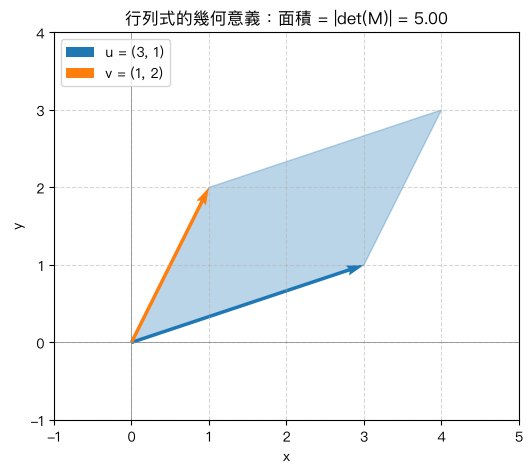

In [12]:
u = np.array([3.0, 1.0])
v = np.array([1.0, 2.0])
M_area = np.array([u, v])

area = abs(np.linalg.det(M_area))
print("向量 u =", u)
print("向量 v =", v)
print("以 u, v 為列的矩陣 M =")
print(M_area)
print("平行四邊形面積 = |det(M)| =", area)

fig, ax = plt.subplots(figsize=(6, 6))
origin = np.array([0.0, 0.0])

parallelogram = np.array([origin, u, u + v, v, origin])
ax.fill(parallelogram[:, 0], parallelogram[:, 1], alpha=0.3, color="tab:blue")
ax.quiver(*origin, *u, angles="xy", scale_units="xy", scale=1,
          color="tab:blue", label="u = (3, 1)")
ax.quiver(*origin, *v, angles="xy", scale_units="xy", scale=1,
          color="tab:orange", label="v = (1, 2)")

ax.set_xlim(-1, 5)
ax.set_ylim(-1, 4)
ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_title(f"行列式的幾何意義：面積 = |det(M)| = {area:.2f}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper left")

fig_path = os.path.join(OUT_DIR, "det_area.png")
plt.savefig(fig_path, dpi=120, bbox_inches="tight")
print("已儲存 2D 面積示意圖至:", fig_path)


## 6. 行列式的幾何意義：3D 平行六面體體積

同理，3x3 矩陣的三列向量 `p`、`q`、`r` 所張成的平行六面體體積等於 `|det([p; q; r])|`。

向量 p = [2. 0. 0.]
向量 q = [0. 2. 0.]
向量 r = [1. 1. 2.]
以 p, q, r 為列的矩陣 M =
[[2. 0. 0.]
 [0. 2. 0.]
 [1. 1. 2.]]
平行六面體體積 = |det(M)| = 7.999999999999998


已儲存 3D 體積示意圖至: /Users/rexwang/workspace/linear-algebra-with-matlab-python-tutorial/ch05_determinants/det_volume.png


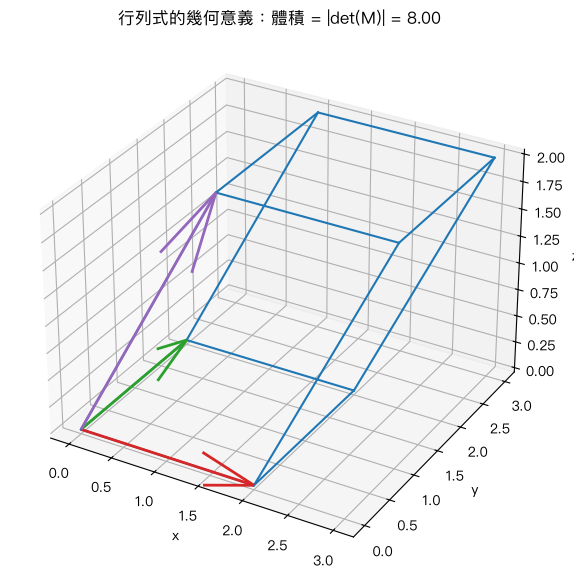

In [13]:
p = np.array([2.0, 0.0, 0.0])
q = np.array([0.0, 2.0, 0.0])
r = np.array([1.0, 1.0, 2.0])
M_volume = np.array([p, q, r])

volume = abs(np.linalg.det(M_volume))
print("向量 p =", p)
print("向量 q =", q)
print("向量 r =", r)
print("以 p, q, r 為列的矩陣 M =")
print(M_volume)
print("平行六面體體積 = |det(M)| =", volume)

fig = plt.figure(figsize=(7, 7))
ax3d = fig.add_subplot(111, projection="3d")

o = np.array([0.0, 0.0, 0.0])
vertices = {
    "O": o, "P": p, "Q": q, "R": r,
    "P+Q": p + q, "P+R": p + r, "Q+R": q + r, "P+Q+R": p + q + r,
}

edges = [
    ("O", "P"), ("O", "Q"), ("O", "R"),
    ("P", "P+Q"), ("P", "P+R"),
    ("Q", "P+Q"), ("Q", "Q+R"),
    ("R", "P+R"), ("R", "Q+R"),
    ("P+Q", "P+Q+R"), ("P+R", "P+Q+R"), ("Q+R", "P+Q+R"),
]

for name_a, name_b in edges:
    pa, pb = vertices[name_a], vertices[name_b]
    ax3d.plot(*zip(pa, pb), color="tab:blue")

ax3d.quiver(*o, *p, color="tab:red", linewidth=2)
ax3d.quiver(*o, *q, color="tab:green", linewidth=2)
ax3d.quiver(*o, *r, color="tab:purple", linewidth=2)

ax3d.set_xlabel("x")
ax3d.set_ylabel("y")
ax3d.set_zlabel("z")
ax3d.set_title(f"行列式的幾何意義：體積 = |det(M)| = {volume:.2f}")

fig_path_3d = os.path.join(OUT_DIR, "det_volume.png")
plt.savefig(fig_path_3d, dpi=120, bbox_inches="tight")
print("已儲存 3D 體積示意圖至:", fig_path_3d)


## 重點整理

- 2x2 行列式：`det(A) = ad - bc`。
- 3x3（以上）行列式可用餘因子展開計算，沿任一列或行展開結果相同。
- 列運算對行列式的影響：交換兩列變號；某列乘 `k` 則行列式乘 `k`；列的倍加不改變行列式。
- `det(A^T) = det(A)`；`det(AB) = det(A) * det(B)`。
- `det(A) = 0` 等價於 `A` 不可逆，也等價於 `A` 的各列（行）線性相依。
- 幾何意義：2D 中 `|det|` 是平行四邊形面積；3D 中 `|det|` 是平行六面體體積。

完整的練習題與答案提示請見 [`ch05_determinants.md`](ch05_determinants.md)。
